# CHAPTER 4: _Introducing Our Datasets_

### Loading the Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2718)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## HMDA

In [ ]:
url = 'https://raw.githubusercontent.com/PacktPublishing/Building-Responsible-AI-with-Python/main/data/hmda.csv'
hmda = pd.read_csv(url, index_col=0)
assert hmda.index.is_unique, "Index is Not Unique"
hmda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300000 entries, 5897023 to 1930962
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   train                          300000 non-null  object 
 1   cv_fold                        240510 non-null  float64
 2   high_priced                    300000 non-null  float64
 3   low_priced                     300000 non-null  float64
 4   interest_rate                  300000 non-null  float64
 5   rate_spread                    300000 non-null  float64
 6   loan_amount                    300000 non-null  float64
 7   loan_to_value_ratio            300000 non-null  float64
 8   no_intro_rate_period           300000 non-null  int64  
 9   intro_rate_period              300000 non-null  int64  
 10  property_value                 300000 non-null  float64
 11  income                         300000 non-null  float64
 12  debt_to_income_ratio_origina

In [ ]:
all(hmda['high_priced'] + hmda['low_priced'] == 1)

True

In [ ]:
hmda['train'].value_counts(dropna=False, normalize=True)

,proportion
train,
train,0.80
valid,0.20


In [ ]:
hmda[hmda['train'] == 'train']['cv_fold'].value_counts(dropna=False, normalize=True)

,proportion
cv_fold,
4.00,0.20
2.00,0.20
3.00,0.20
5.00,0.20
1.00,0.20


In [ ]:
combined_result = pd.DataFrame({
    'sex_column': hmda['sex'].value_counts(dropna=False),
    'female_column': hmda['female'].map({0.0: 'Male', 1.0: 'Female', np.nan: 'Unknown'}).value_counts(),
    'male_column': hmda['male'].map({1.0: 'Male', 0.0: 'Female', np.nan: 'Unknown'}).value_counts()
}).fillna(0).astype(int)

display(combined_result)

,sex_column,female_column,male_column
Unknown,138217,138217,138217
Male,98786,98786,98786
Female,62997,62997,62997


In [ ]:
hmda['race'].value_counts(dropna=False, normalize=True)\
    .map(lambda x: f"{x:.4f}")

,proportion
race,
White,0.7178
Unknown,0.1410
Asian,0.0675
Black,0.0674
Native american,0.0041
Hawaiian or pacific islander,0.0023


In [ ]:
hmda['ethnicity'].value_counts(dropna=False, normalize=True)

,proportion
ethnicity,
Non-Hispanic,0.76
Unknown,0.14
Hispanic,0.10


In [ ]:
age_combined_distribution = pd.DataFrame({
    'agegte62': hmda['agegte62'].value_counts(dropna=False, normalize=True),
    'agelt62': hmda['agelt62'].value_counts(dropna=False, normalize=True)
})

display(age_combined_distribution.fillna(0).map(lambda x: f'{x:.2f}'))

,agegte62,agelt62
0.00,0.40,0.11
1.00,0.11,0.40
NaN,0.49,0.49


In [ ]:
hmda[['state', 'state_target_encoded']].head()

,state,state_target_encoded
5897023,CO,0.08
1879906,MS,0.09
1862043,SC,0.09
4589390,TX,0.17
4342060,NC,0.08


In [ ]:
f"{hmda.loc[hmda['state'] == 'TX', 'high_priced'].mean():.2f}"

'0.17'

In [ ]:
round(hmda.loc[hmda['state'] == 'TX', 'high_priced'].mean(), 2)

np.float64(0.17)

In [ ]:
hmda[['debt_to_income_ratio_original', 'debt_to_income_ratio']].head(2)

,debt_to_income_ratio_original,debt_to_income_ratio
5897023,46,0.46
1879906,20%-<30%,0.25


In [ ]:
hmda.iloc[30:36][['no_intro_rate_period', 'intro_rate_period']]

,no_intro_rate_period,intro_rate_period
1220136,0,180
2287610,1,0
3713370,1,0
839246,1,0
2980352,1,0
395197,0,121


In [ ]:
hmda['high_priced'].value_counts(normalize=True)

,proportion
high_priced,
0.00,0.90
1.00,0.10


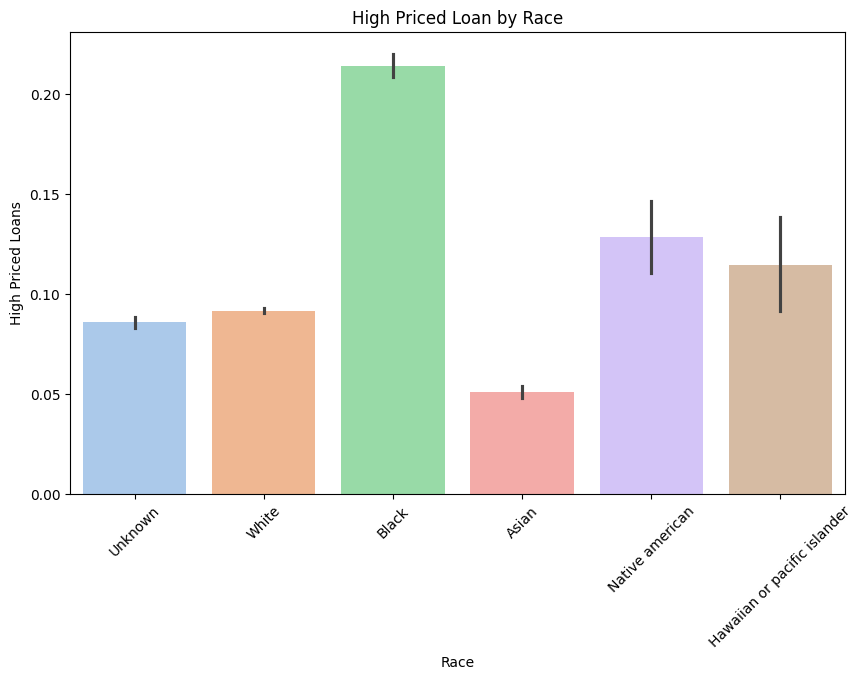

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='race', y='high_priced', hue='race', data= hmda, palette='pastel')
plt.xlabel('Race')
plt.ylabel('High Priced Loans')
plt.title('High Priced Loan by Race')
plt.xticks(rotation=45)
plt.show()

## CES

In [2]:
url = 'https://raw.githubusercontent.com/PacktPublishing/Building-Responsible-AI-with-Python/main/data/consumer_expenditure_survey.csv.gz'
ces = pd.read_csv(url, index_col='CUID')
assert ces.index.is_unique, "Index is Not Unique"
ces.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16789 entries, 257896 to 457928
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Data                          16789 non-null  object 
 1   Fold                          10148 non-null  float64
 2   Date                          16789 non-null  object 
 3   Year                          16789 non-null  int64  
 4   Month                         16789 non-null  int64  
 5   Income Before Taxes           16789 non-null  float64
 6   Number of Bedrooms            16708 non-null  float64
 7   Number of Bathrooms           16712 non-null  float64
 8   State                         16789 non-null  object 
 9   Urban                         16789 non-null  int64  
 10  People                        16789 non-null  int64  
 11  Adults                        16789 non-null  int64  
 12  65 or Older                   16789 non-null  int64  
 13  

In [13]:
unique_dates_by_data = ces.groupby('Data').agg({
    'Year': lambda x: sorted(x.unique()),
    'Month': lambda x: sorted(x.unique()),
    'Fold': lambda x: sorted(x.unique())
})

display(unique_dates_by_data)

,Year,Month,Fold
Data,,,
OOT-2019,[2019],"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[nan]
OOT-2020,[2020],"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",[nan]
Test,"[2013, 2014, 2015, 2016, 2017, 2018]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[nan]
Train,"[2013, 2014, 2015, 2016, 2017, 2018]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[1.0, 2.0, 3.0, 4.0, 5.0]"


In [11]:
ces['Data'].value_counts(dropna=False, normalize=True)

,proportion
Data,
Train,0.60
Test,0.15
OOT-2019,0.12
OOT-2020,0.12


In [10]:
ces[ces['Data'] == 'Train']['Fold'].value_counts(dropna=False, normalize=True)

,proportion
Fold,
2.00,0.20
5.00,0.20
3.00,0.20
4.00,0.20
1.00,0.20


In [15]:
train = ces.loc[ces['Data'] == 'Train', :].copy()
valid = ces.loc[ces['Data'] == 'Test', :].copy()
oot= ces.loc[ces['Data'].isin(['OOT-2019', 'OOT-2020']), :].copy()
print(train.shape, valid.shape, oot.shape)

(10148, 28) (2579, 28) (4062, 28)


In [13]:
result_df = ces \
    .groupby('High lead-Food-Away Spending')['lead-Food-Total'] \
    .agg(['min', 'max']) \
    .round(2)
display(result_df)

,min,max
High lead-Food-Away Spending,,
0,14.55,18451.52
1,2337.52,26852.98


In [4]:
ces['High lead-Food-Away Spending'].value_counts(normalize=True)

,proportion
High lead-Food-Away Spending,
0,0.91
1,0.09


In [21]:
for col in ['Education', 'Race', 'Sex']:
    print(col, sorted(ces[col].dropna().unique()))

Education ['Bachelors', 'Graduate Degree', 'High School', 'Less than High School', 'Some College']
Race ['Asian/PI', 'Black', 'Multi or Other Race', 'White']
Sex ['Female', 'Male', 'Mixed Gender']


## Synthetic Dataset

In [7]:
url = 'https://raw.githubusercontent.com/PacktPublishing/Building-Responsible-AI-with-Python/main/data/simulated_df.csv.gz'
df = pd.read_csv(url, compression='gzip')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 44 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           300000 non-null  int64  
 1   train        300000 non-null  object 
 2   minority     300000 non-null  int64  
 3   majority     300000 non-null  int64  
 4   y            300000 non-null  float64
 5   y_binary     300000 non-null  int64  
 6   x1           300000 non-null  float64
 7   x2           300000 non-null  float64
 8   x3           300000 non-null  float64
 9   x4           300000 non-null  float64
 10  x5           300000 non-null  float64
 11  x6           300000 non-null  float64
 12  x7           300000 non-null  float64
 13  x8           300000 non-null  float64
 14  x9           300000 non-null  float64
 15  x10          300000 non-null  float64
 16  x11          300000 non-null  float64
 17  x12          300000 non-null  float64
 18  x13_pre_cat  300000 non-

In [10]:
df['train'].value_counts(normalize=True)

,proportion
train,
train,0.80
valid,0.20


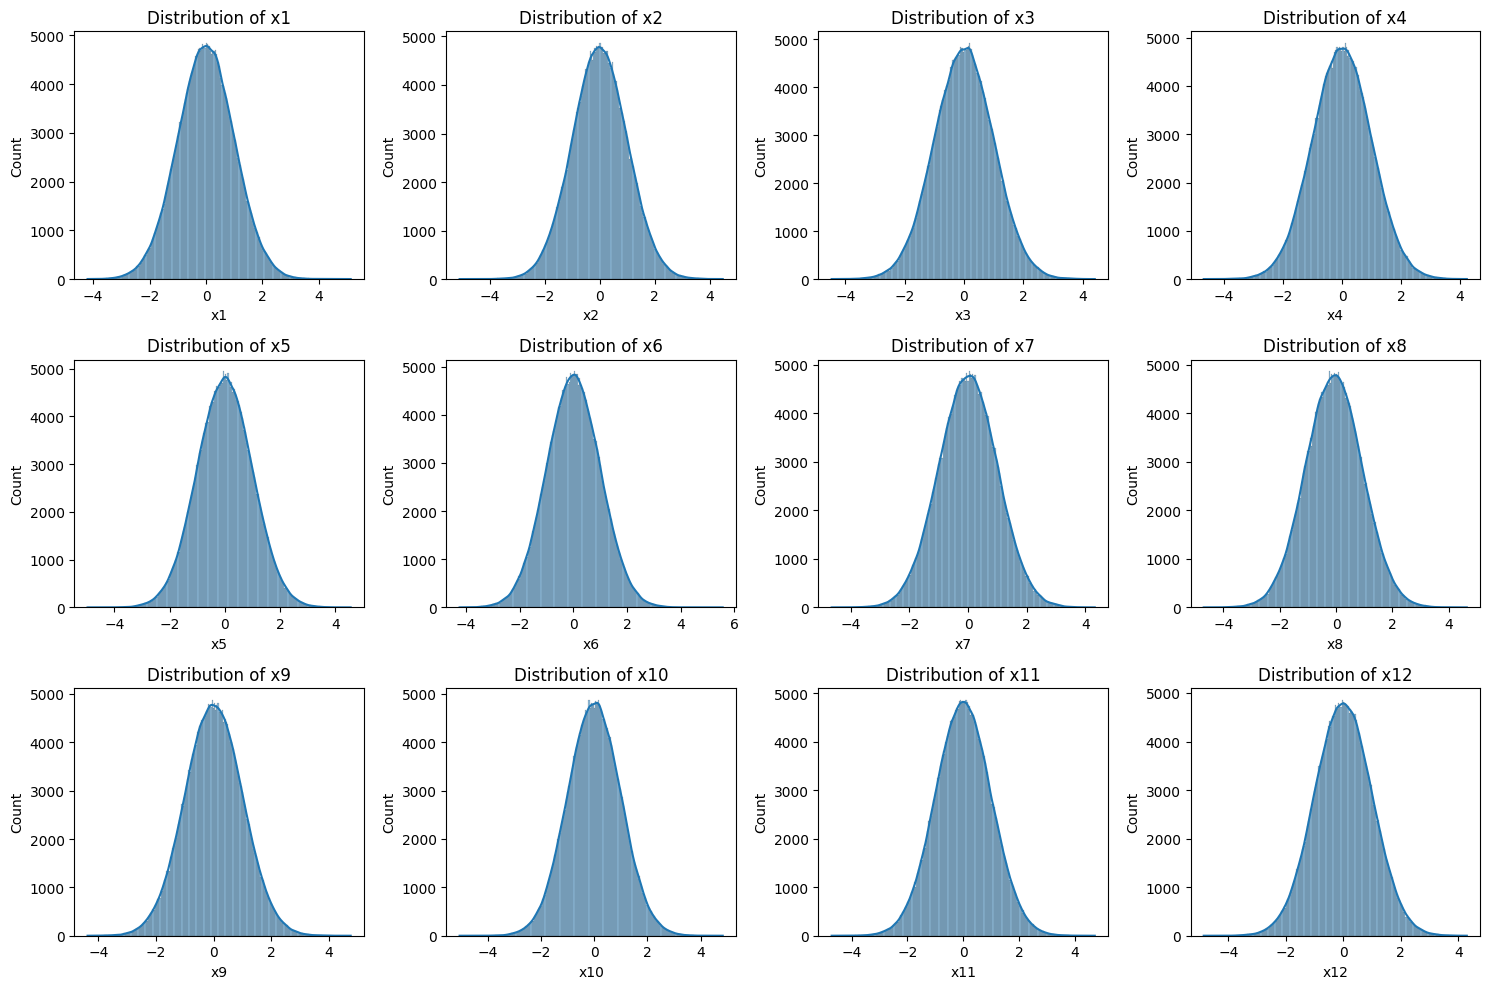

In [12]:
continuous_features = [f'x{i}' for i in range(1, 13)]

plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_features):
    plt.subplot(3, 4, i + 1) # 3 rows, 4 columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [23]:
for col in ['x13_cat','x14_cat' ]:
    print(col, sorted(df[col].dropna().unique()))

df[['x13_cat', 'x13_B', 'x13_C', 'x13_D', 'x13_E', 'x14_cat', 'x14_B', 'x14_C', 'x14_D', 'x14_E']].head(10)

x13_cat ['A', 'B', 'C', 'D', 'E']
x14_cat ['A', 'B', 'C', 'D', 'E']


,x13_cat,x13_B,x13_C,x13_D,x13_E,x14_cat,x14_B,x14_C,x14_D,x14_E
0,C,0,1,0,0,C,0,1,0,0
1,E,0,0,0,1,C,0,1,0,0
2,C,0,1,0,0,B,1,0,0,0
3,B,1,0,0,0,B,1,0,0,0
4,D,0,0,1,0,D,0,0,1,0
5,E,0,0,0,1,D,0,0,1,0
6,E,0,0,0,1,D,0,0,1,0
7,B,1,0,0,0,B,1,0,0,0
8,B,1,0,0,0,A,0,0,0,0
9,C,0,1,0,0,C,0,1,0,0


In [3]:
all(df['minority'] + df['majority'] == 1)

True

In [21]:
print(df['y_binary'].value_counts(normalize=True))

y_binary
0   0.76
1   0.24
Name: proportion, dtype: float64
